In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:/Users/Jayita/Documents/customer-churn-ai/data/customer_churn.csv")


In [4]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape


(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df["customerID"].duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

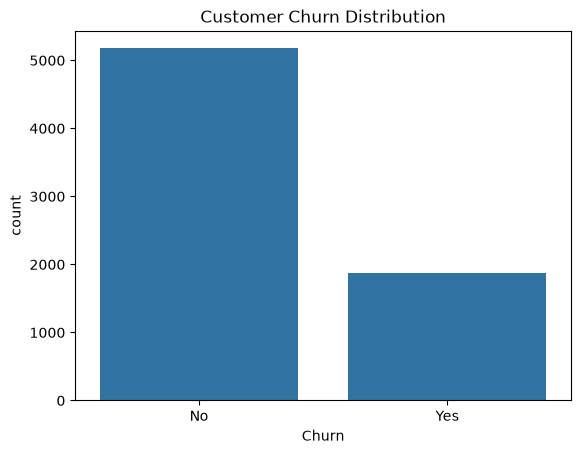

In [14]:
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

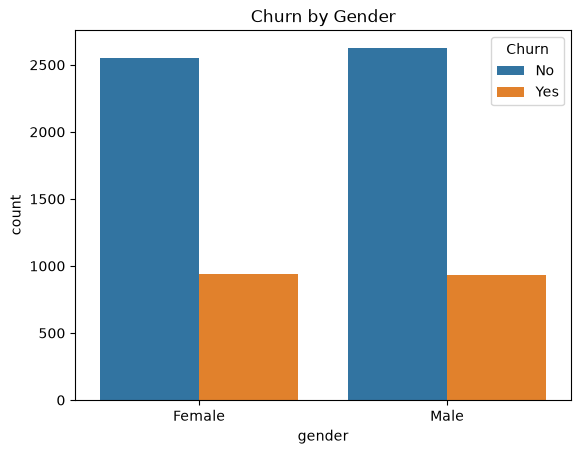

In [15]:
sns.countplot(data=df, x="gender", hue="Churn")
plt.title("Churn by Gender")
plt.show()

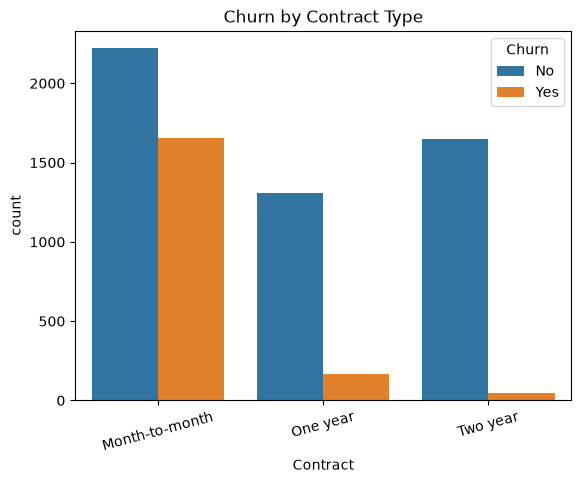

In [16]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

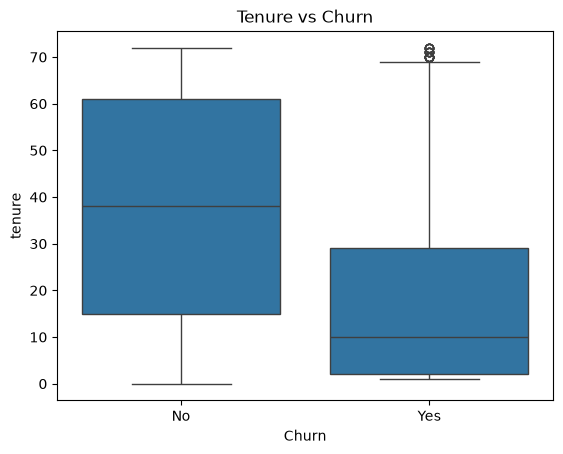

In [17]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.show()

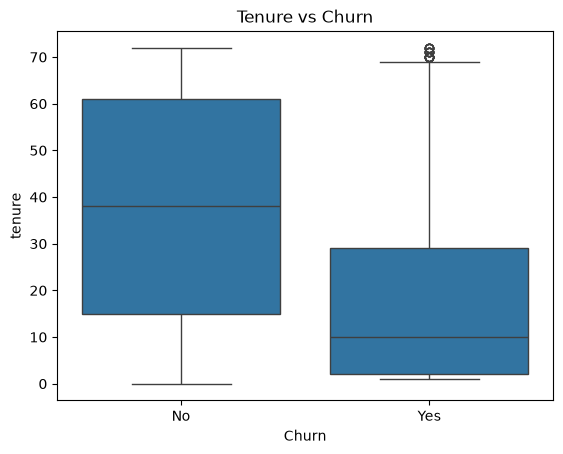

In [18]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.show()

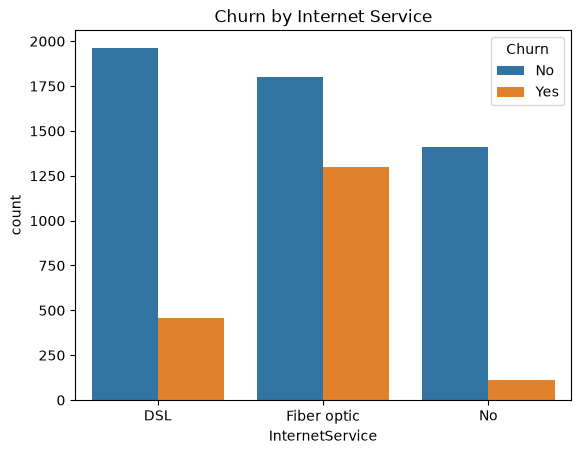

In [19]:
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.show()

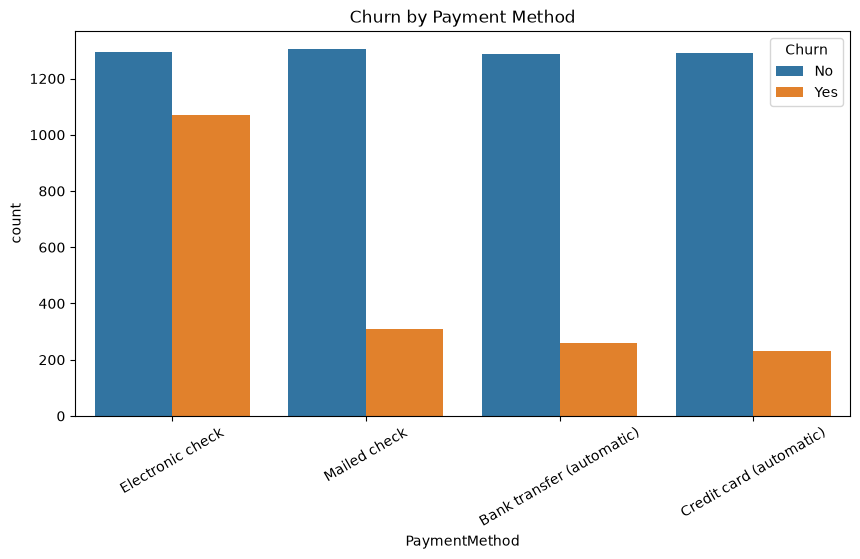

In [20]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Churn by Payment Method")
plt.xticks(rotation=30)
plt.show()

In [21]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [22]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.00000,0.247900,0.825880
MonthlyCharges,0.24790,1.000000,0.651065
TotalCharges,0.82588,0.651065,1.000000


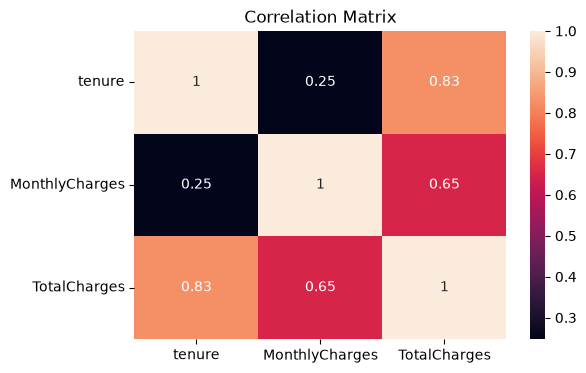

In [23]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(),
    annot=True
)

plt.title("Correlation Matrix")
plt.show()

In [24]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [25]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [26]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


## EDA Findings

1. The dataset contains approximately 7,043 customers and 21 features.

2. The target variable is Churn, with Yes and No as the two classes.

3. Approximately 26.5% of customers have churned.

4. The dataset contains more non-churn customers than churn customers.

5. Month-to-month contract customers show substantially higher churn.

6. Customers with shorter tenure tend to have higher churn.

7. Monthly charges show differences between churned and non-churned customers.

8. Internet service and payment method appear to have relationships with churn.

9. TotalCharges requires numeric conversion because some values are stored as text/blank values.

10. Several categorical variables will require encoding before machine learning.

In [27]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/customer_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [29]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [30]:
errors="coerce"

In [31]:
df["TotalCharges"].dtype

dtype('float64')

In [33]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [34]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [35]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [36]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df["customerID"].duplicated().sum()

np.int64(0)

In [39]:
df = df.drop("customerID", axis=1)

In [40]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [41]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [42]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [43]:
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: str

In [44]:
y = y.map({
    "No": 0,
    "Yes": 1
})

In [45]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [46]:
categorical_columns = X.select_dtypes(
    include=["object"]
).columns

categorical_columns

C:\Users\Jayita\AppData\Local\Temp\ipykernel_6532\4091277228.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [47]:
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

numerical_columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

In [48]:
from sklearn.model_selection import train_test_split                                      

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
stratify=y

In [51]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 19)
Testing data: (1409, 19)


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [54]:
handle_unknown="ignore"

In [55]:
X_train_processed = preprocessor.fit_transform(X_train)

In [57]:
X_test_processed = preprocessor.transform(X_test)

In [58]:
print("Before preprocessing:", X_train.shape)
print("After preprocessing:", X_train_processed.shape)

Before preprocessing: (5634, 19)
After preprocessing: (5634, 45)


In [59]:
print(y_train.value_counts())
print(y_test.value_counts())

Churn
0    4139
1    1495
Name: count, dtype: int64
Churn
0    1035
1     374
Name: count, dtype: int64


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/Jayita/Documents/customer-churn-ai/data/customer_churn.csv")

In [2]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [3]:
df["average_monthly_spend"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

In [4]:
df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "average_monthly_spend"
    ]
].head(10)

,tenure,MonthlyCharges,TotalCharges,average_monthly_spend
0,1,29.85,29.85,29.850000
1,34,56.95,1889.50,55.573529
2,2,53.85,108.15,54.075000
3,45,42.30,1840.75,40.905556
4,2,70.70,151.65,75.825000
5,8,99.65,820.50,102.562500
6,22,89.10,1949.40,88.609091
7,10,29.75,301.90,30.190000
8,28,104.80,3046.05,108.787500
9,62,56.15,3487.95,56.257258


In [6]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [7]:
df["total_services"] = (
    df[service_columns] == "Yes"
).sum(axis=1)

In [8]:
df[
    ["customerID", "total_services"]
].head(10)

,customerID,total_services
0,7590-VHVEG,1
1,5575-GNVDE,3
2,3668-QPYBK,3
3,7795-CFOCW,3
4,9237-HQITU,1
5,9305-CDSKC,5
6,1452-KIOVK,4
7,6713-OKOMC,1
8,7892-POOKP,6
9,6388-TABGU,3


In [9]:
df["total_services"].describe()

count    7043.000000
mean        3.362914
std         2.062031
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max         8.000000
Name: total_services, dtype: float64

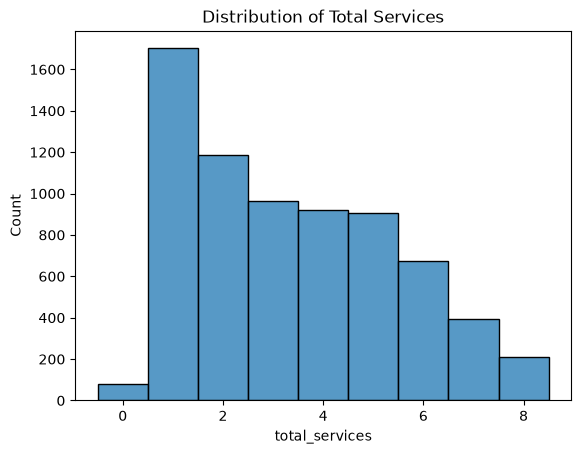

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(
    data=df,
    x="total_services",
    discrete=True
)

plt.title("Distribution of Total Services")
plt.show()

In [11]:
df["is_new_customer"] = (
    df["tenure"] <= 6
).astype(int)

In [12]:
df[
    ["tenure", "is_new_customer"]
].head(20)

,tenure,is_new_customer
0,1,1
1,34,0
2,2,1
3,45,0
4,2,1
5,8,0
6,22,0
7,10,0
8,28,0
9,62,0


In [13]:
pd.crosstab(
    df["is_new_customer"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
is_new_customer,,
0,80.492629,19.507371
1,47.062795,52.937205


In [14]:
pd.crosstab(
    df["is_new_customer"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
is_new_customer,,
0,80.492629,19.507371
1,47.062795,52.937205


In [15]:
df["has_internet"] = (
    df["InternetService"] != "No"
).astype(int)

In [16]:
df[
    ["InternetService", "has_internet"]
].head(10)

,InternetService,has_internet
0,DSL,1
1,DSL,1
2,DSL,1
3,DSL,1
4,Fiber optic,1
5,Fiber optic,1
6,Fiber optic,1
7,DSL,1
8,Fiber optic,1
9,DSL,1


In [18]:
df["has_support"] = (
    (df["OnlineSecurity"] == "Yes") |
    (df["TechSupport"] == "Yes")
).astype(int)

In [19]:
df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "average_monthly_spend",
        "total_services",
        "is_new_customer",
        "has_internet",
        "has_support",
        "Churn"
    ]
].head(10)

,tenure,MonthlyCharges,TotalCharges,average_monthly_spend,total_services,is_new_customer,has_internet,has_support,Churn
0,1,29.85,29.85,29.850000,1,1,1,0,No
1,34,56.95,1889.50,55.573529,3,0,1,1,No
2,2,53.85,108.15,54.075000,3,1,1,1,Yes
3,45,42.30,1840.75,40.905556,3,0,1,1,No
4,2,70.70,151.65,75.825000,1,1,1,0,Yes
5,8,99.65,820.50,102.562500,5,0,1,0,Yes
6,22,89.10,1949.40,88.609091,4,0,1,0,No
7,10,29.75,301.90,30.190000,1,0,1,1,No
8,28,104.80,3046.05,108.787500,6,0,1,1,Yes
9,62,56.15,3487.95,56.257258,3,0,1,1,No


In [21]:
pd.crosstab(
    df["total_services"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
total_services,,
0,56.250000,43.750000
1,78.894768,21.105232
2,67.171717,32.828283
3,63.523316,36.476684
4,68.655098,31.344902
5,74.449339,25.550661
6,77.514793,22.485207
7,87.594937,12.405063
8,94.711538,5.288462


In [22]:
pd.crosstab(
    df["has_internet"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
has_internet,,
0,92.595020,7.404980
1,68.171107,31.828893


In [23]:
pd.crosstab(
    df["has_support"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
has_support,,
0,66.584947,33.415053
1,82.928475,17.071525


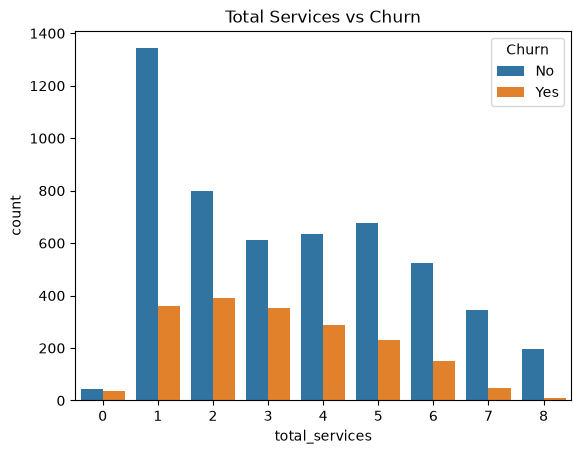

In [24]:
sns.countplot(
    data=df,
    x="total_services",
    hue="Churn"
)

plt.title("Total Services vs Churn")
plt.show()

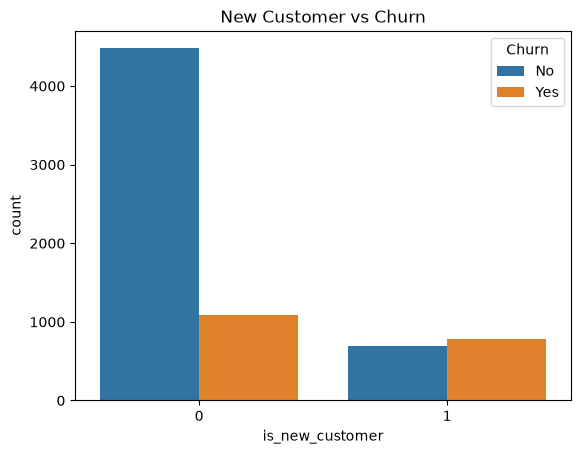

In [25]:
sns.countplot(
    data=df,
    x="is_new_customer",
    hue="Churn"
)

plt.title("New Customer vs Churn")
plt.show()

In [26]:
df[
    [
        "average_monthly_spend",
        "total_services",
        "is_new_customer",
        "has_internet",
        "has_support"
    ]
].describe()

,average_monthly_spend,total_services,is_new_customer,has_internet,has_support
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,64.762906,3.362914,0.210280,0.783331,0.420843
std,30.189796,2.062031,0.407536,0.412004,0.493730
min,13.775000,0.000000,0.000000,0.000000,0.000000
25%,35.935156,1.000000,0.000000,1.000000,0.000000
50%,70.337500,3.000000,0.000000,1.000000,0.000000
75%,90.174158,5.000000,0.000000,1.000000,1.000000
max,121.400000,8.000000,1.000000,1.000000,1.000000


In [27]:
(df["average_monthly_spend"] < 0).sum()

np.int64(0)

In [28]:
df[
    [
        "average_monthly_spend",
        "total_services",
        "is_new_customer",
        "has_internet",
        "has_support"
    ]
].isnull().sum()

average_monthly_spend    0
total_services           0
is_new_customer          0
has_internet             0
has_support              0
dtype: int64